# Lecture 6 - Basic Statistics II

---




## Today's Key Takeaways
- Type I error
  -  Multiple hypothesis testing
- Type II error
  - Statistical power



## Basic Statistics with `scipy` and `statsmodels`

The `scipy` library expands the `numpy` suite of mathematical functions. Like `numpy`, these are broken up into sublibraries.

Note that we used a new method of importing. Some libraries, like scipy, have multiple sub-libraries. You can import just the sub-library using the `from` command. This saves memory and time.

We are mostly going to use the stats sublibrary, but we imported all of scipy so we can look over the help file and functions.



In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import statsmodels.stats.multitest as smm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import seaborn as sns
import math

In [2]:
pd.set_option('display.precision', 2)
pd.set_option('display.max_columns',10)


### Start by importing our expression dataset

We're going to start by importing data the expression-metadata merged spreadsheet, so that we've got something to work with.

In [3]:
# importing the melanoma dataset
melanoma_log2 = pd.read_excel('~/LECTURE_MATERIALS/DataFiles/melanoma_zerosRemoved_log2transformed_2026.xlsx',index_col = 0)
melanoma_log2.head()

,Sample_geo_accession,Stage,cell type,sample_number,cell_line,...,ZYX,ZZEF1,ZZZ3,BP-21201H5.1,BP-2189O9.2
Sample Title,,,,,,,,,,,
FM_1,GSM2344965,primary melanocytes,normal melanocytes,1,FM,...,11.66,11.83,10.55,3.17,1.00
FM_2,GSM2344966,primary melanocytes,normal melanocytes,2,FM,...,11.63,11.54,11.06,2.81,2.00
FM_3,GSM2344967,primary melanocytes,normal melanocytes,3,FM,...,12.31,11.44,10.81,2.32,1.58
SK_MEL_28_1,GSM2344968,metastatic,melanoma cell line,4,SK_MEL_28,...,11.86,10.94,11.64,0.00,6.04
SK_MEL_28_2,GSM2344969,metastatic,melanoma cell line,5,SK_MEL_28,...,11.97,11.03,11.74,1.00,6.41


### Initial data processing

We're going to calculate the top variably expressed genes, as we've done before, and we're going to save the top 100 variably expressed genes both as a variable, and as an Excel spreadsheet that we're going to download.

In [4]:
# calculates the overall variance df.var() and sorts it in descending order
overall_variance = melanoma_log2.loc[:,'A1BG':].var()
overall_variance.sort_values(inplace = True, ascending= False)
overall_variance.head()

# extract gene names for top 100 most variably expressed genes
topvarGens100 = overall_variance.index[:100].to_list()

# Create a data frame containing all the relevant variables
data = pd.DataFrame({'Top100': topvarGens100})

data.to_excel('TopVarGens100.xlsx')
data.head()

,Top100
0,PMEL
1,TYRP1
2,AEBP1
3,GLUL
4,TYR


## Type I errors

A **Type I error** is when you incorrectly conclude that two sets of observations are from different distributions even though they are from the same distribution

The p-value enumerates the type I error of a statistical test for any individual statistical test.

Notice below when we draw observations from the same distribution: if we only have 10 observations we may sometimes get p-values < 0.05, which might lead us to conclude falsely that the two samples are from different distributions.


## Multiple Hypothesis Testing

We're going to demonstrate the challenge of multiple hypothesis testing by generating an artificial dataset of expression values for 1000 genes, 5 of which are differentially expressed.

In [34]:
# We will start by setting a random seed so that all our random variables match
np.random.seed(10)

In [35]:
# A random integer with randint(start, stop(not included), number of values desired)
d1 = np.random.normal(loc=0, scale = 1, size=(1000,10)) #expression of each gene has mean 0, standard deviation 1
d2 = np.vstack((np.random.normal(loc=0, scale = 1, size=(10,10))+2,np.random.normal(loc=0, scale = 1, size=(990,10)))) #expression of 10 of the genes has mean 2, standard deviation 1; rest have mean 0, standard deviation 1

# Creating a data frame with the random numbers that we've generated
dfrand = pd.DataFrame(data = np.hstack((d1,d2)))
dfrand.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','B1','B2','B3','B4','B5','B6','B7','B8','B9','B10']
print(dfrand.shape)
dfrand.head(10)

(1000, 20)


,A1,A2,A3,A4,A5,...,B6,B7,B8,B9,B10
0,1.33,0.72,-1.55,-8.38e-03,0.62,...,2.09,0.83,1.21,1.99,1.75
1,0.43,1.20,-0.97,1.03e+00,0.23,...,2.94,3.53,2.47,0.40,2.82
2,-1.98,-1.74,0.27,2.38e+00,1.12,...,1.71,2.34,1.31,2.07,2.19
3,-0.27,-0.55,0.13,-4.76e-01,1.31,...,1.40,1.83,0.85,3.10,3.12
4,0.66,-0.35,-0.94,-4.89e-01,-0.80,...,1.82,2.71,2.02,1.72,1.54
5,-0.03,0.29,-0.54,7.08e-01,0.84,...,1.65,3.42,1.45,1.29,2.98
6,-0.23,-0.50,1.13,-6.98e-01,-0.08,...,2.76,3.50,3.27,3.61,0.23
7,0.32,0.46,-0.22,9.89e-01,0.31,...,0.11,1.60,1.15,2.38,3.81
8,1.99,1.74,-1.86,-2.23e-01,-0.07,...,1.20,1.86,2.52,3.80,1.76
9,1.11,0.24,-0.06,-7.54e-01,0.71,...,3.21,1.96,1.12,1.80,0.65


In [36]:
# Evaluating significance using a t-test for each row of this data frame using a for-loop
pRand = np.zeros(1000)

for i in range(0,1000):
    stat, p = stats.ttest_ind(dfrand.iloc[i,:10], dfrand.iloc[i,10:]) #t-test for the ith gene for the A samples (first 6 columns) vs. the B samples (last 6 columns)
    pRand[i] = p


If we plot what the p-values look like in a histogram, we see that they take on basically every value uniformly.

Text(0.5, 0, 'P-value')

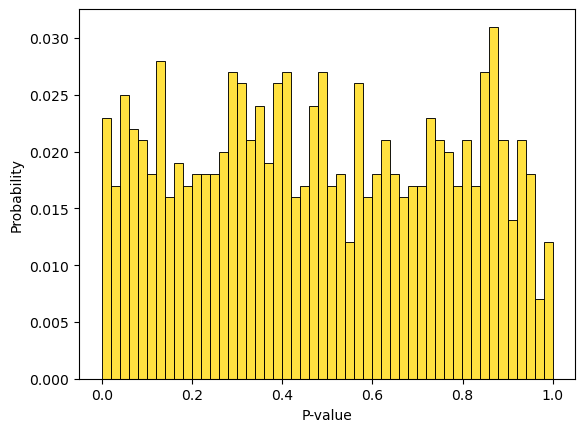

In [37]:
g = sns.histplot(pRand, stat='probability',
                 cumulative=False,
                 color='gold', bins=50)
plt.xlabel('P-value')


And if we check how many p-values are less than 0.05:

In [38]:
print(pRand[:10])
print(sum(pRand < 0.05))

[7.84680359e-04 5.11711336e-03 4.19702330e-03 3.85878905e-04
 7.61164312e-06 5.45004863e-04 1.89342434e-06 2.00959307e-03
 1.75303827e-03 1.43901292e-04]
54


There are about ~50 genes with p-value of 0.05 (i.e. roughly 5% of the rows generate a p-value of <0.05).

## Multiple hypothesis correction

If we need to perform many statistical tests at a time (e.g. evaluating transcriptome data for differentially expressed genes), we open ourselves to the risk of finding spurious associations that have low p-values by chance. Correction methods can adjust the raw p-value to try to compensate for this.

### Bonferroni Correction

Typically more stringent, may leave some significant genes out

In [39]:
# Multiple Hypothesis Correction with Bonferroni
pval_correctedB = smm.multipletests(pRand, alpha=0.05, method='bonferroni')[1]
print(sum(pval_correctedB < 0.05)) # the corrected p-values by Bonferroni

3


In [41]:
print(pval_correctedB[:10])

[0.78468036 1.         1.         0.38587891 0.00761164 0.54500486
 0.00189342 1.         1.         0.14390129]


### Benjamini-Hochberg FDR correction

More balanced correction

In [40]:
# Multiple Hypothesis Correction with Benjamini-Hochberg FDR
pval_correctedFDR = smm.multipletests(pRand, alpha=0.05, method='fdr_bh')[1]

print(sum(pval_correctedFDR < 0.05)) # the corrected p-values by FDR


4


Summarizing the p-values in a data frame for easier comparison

In [42]:
# Creating the data frame with a Python dictionary
dfrandP = pd.DataFrame({'Raw_Pvalues':pRand, "FDR_Corrected_Pvalues": pval_correctedFDR, "Bonferroni_Corrected_Pvalues": pval_correctedB},index = dfrand.index)
dfrandP.head(15)

,Raw_Pvalues,FDR_Corrected_Pvalues,Bonferroni_Corrected_Pvalues
0,7.85e-04,1.12e-01,7.85e-01
1,5.12e-03,3.66e-01,1.00e+00
2,4.20e-03,3.23e-01,1.00e+00
3,3.86e-04,7.72e-02,3.86e-01
4,7.61e-06,3.81e-03,7.61e-03
5,5.45e-04,9.08e-02,5.45e-01
6,1.89e-06,1.89e-03,1.89e-03
7,2.01e-03,1.81e-01,1.00e+00
8,1.75e-03,1.75e-01,1.00e+00
9,1.44e-04,3.60e-02,1.44e-01


Exporting data to Excel

In [43]:
dfrand.to_excel('dfRand_MultiHypothesisToy.xlsx')

In [44]:
dfrandP.to_excel('dfRand_MultiHypothesisToyP.xlsx')

## Type-II errors

A **type-I error** occurs when we mistakenly conclude there is a difference, when there is no actual difference.

A **type-II error** occurs when we mistakenly conclude that there is no difference, when there actually *IS* a difference.

A type-II error can occur when we don't have a large enough sample to see a difference. Take the example below when there are two distributions: the mean of one distribution is 1 while the other is 0, but with only 10 observations from each, they look the same (and the t-test has p > 0.05)

T-test p-value: 0.420


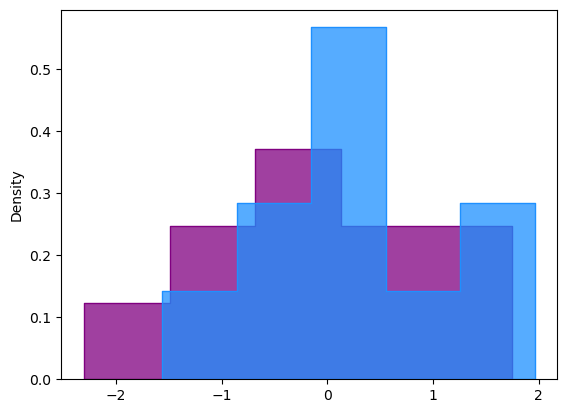

In [55]:
np.random.seed(1)
n_samples = 10 # number of samples per group

# Note: The effect size is the difference of the means between groups a and b (relative to the "scale" value)
mean_a = 0 # mean of distribution for group a
mean_b = 0.5 # mean of distribution for group b. Set for effect size = 0.5

# Purple plot: mean=0
data_a = np.random.normal(loc=mean_a, scale=1, size=(n_samples,))
sns.histplot(data_a, stat='density', color='purple', element='step')

# Blue plot: mean=0.5
data_b = np.random.normal(loc=mean_b, scale=1, size=(n_samples,))
sns.histplot(data_b, stat='density', color='dodgerblue', element='step')

# Run a t-test comparing the two samples
tstat, p = stats.ttest_ind(data_a, data_b)
print(f'T-test p-value: {p:1.3f}')

## Power

**Power** is (one minus) the chance of making a type-II error given three factors/parameters:
 - sample size (n)
 - variance (or standard deviation)
 - actual difference (aka effect size)

With higher *n* you are less likely to make a type-II error and so you have more power.

With less variability in your observations you have more power.

With a greater effect size you have more power.

## Sample size calculations

For a comparison of random variables from two conditions (e.g., treatment A and treatment B) we want to design an experiment that has sufficient power for us to conclude there is a difference, if the actual difference is of a pre-specified magnitude. We can estimate power if we make assumptions about:
 - sample size
 - equal variance of the distributions
 - effect size of X
Then we can vary the sample size of the experiment until power >80-90% (typically sufficient)

We can use a simulation to estimate power!
1) Simulate an experiment with samples from two random variables having different means
2) Test whether the two samples are different using a t-test
3) Repeat 1000 times with random samples and count how many times the t-test yields a significant result
4) Power = proportion of simulations that yielded a significant result

In [56]:
n_experiments = 1000 # number of repeat experiments
n_samples = 10 # number of samples per group

# Note: The effect size is the difference of the means between groups a and b (relative to the "scale" value)
mean_a = 0 # mean of distribution for group a
mean_b = 0.5 # mean of distribution for group b. Set for effect size = 0.5

pvalues = np.zeros(n_experiments) # initiate variable to store p-values for each iteration.
for i in range(n_experiments): # iterate over number of experiments
    data_a = np.random.normal(loc=mean_a, scale=1, size=(n_samples,)) # create random sample group a
    data_b = np.random.normal(loc=mean_b, scale=1, size=(n_samples,)) # create random sample group b
    tstat, p = stats.ttest_ind(data_a, data_b) # perform t-test between a and b
    pvalues[i] = p # store the t-test p-value

power = np.sum(pvalues < 0.05) / n_experiments

print(f'Power: {power:1.2f}')

Power: 0.17


Let's run a simulation to estimate the sample size needed to have >80% power to detect a difference in the mean of 0.5 when the distributions are normally distributed with variance/scale equal to 1?

Construct a loop over many possible *n*'s to find the lowest *n* that has power > 0.8.

set of sample sizes: [10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50 52 54 56
 58 60 62 64 66 68 70 72 74 76 78]


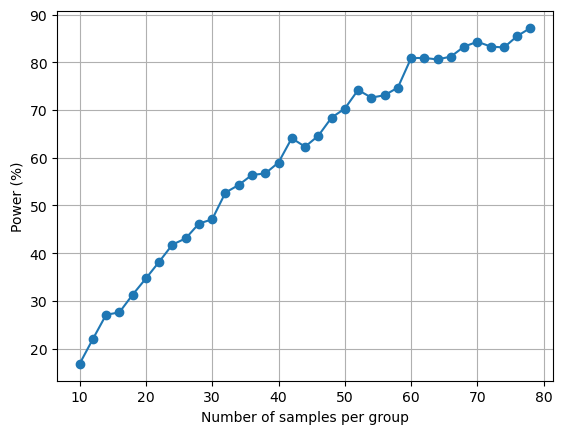

In [57]:
n_experiments = 1000 # number of experiments trialed per sample size
n_samples_vector = np.arange(10, 80, 2) # set of sample sizes to test
print('set of sample sizes:', n_samples_vector)

# Note: The effect size is the difference of the means between groups a and b (relative to the "scale" value)
mean_a = 0 # mean of distribution for group a
mean_b = 0.5 # mean of distribution for group b. Set for effect size = 0.5

powers = np.zeros(len(n_samples_vector))
for samp_i, n_samples in enumerate(n_samples_vector):
  pvalues = np.zeros(n_experiments)
  for i in range(n_experiments):
      data_a = np.random.normal(loc=mean_a, scale=1, size=(n_samples,))
      data_b = np.random.normal(loc=mean_b, scale=1, size=(n_samples,))
      tstat, p = stats.ttest_ind(data_a, data_b)
      pvalues[i] = p

  powers[samp_i] = np.sum(pvalues < 0.05) / n_experiments


plt.plot(n_samples_vector, 100*powers, '-o')
plt.xlabel('Number of samples per group')
plt.ylabel('Power (%)')
plt.grid('both')

Power simulation result:

The above code runs a power simulation for sample sizes between 10 and 80. We can see that with ~65 samples per group we had approximately 80% power to detect the difference in mean of 0.5, assuming a standard deviation of 1.

This result makes sense too because a shift in mean of 0.5 is quite small relative to the standard deviation, so we would need to collect a lot of samples before we'd have enough evidence to reject the null hypothesis.

### <font color=brown>Hands on practice</font>

1. Adjust the code above to plot and estimate find how many samples are needed to reach a statistical power of 80% when the effect size is 1.



2. Adapt the code above to estimate and plot how much statistical power we in detecting a significant difference between the expression of the gene PMEL in metastatic vs. primary melanocytes. *Hint* you'll need to calculate the mean and standard deviations of PMEL in each stage.

In [ ]:
# calculate the means by stage


In [ ]:
# Calculate the standard deviations by stage


In [ ]:
# power simulation for loop and plotting